# 07 — Phase 2 v0: XGBoost Baseline Delay Model

Trains a v0 baseline regressor for `delay_minutes` on the engineered feature
snapshot from `s3://seq-transit-ai-data-ps/ml_features/v0_feature_snapshot/`
(same load pattern as notebook 06).

Key steps:
1. Load the versioned parquet via the `_latest.json` run pointer.
2. **Leakage filter**: drop rows captured after the scheduled arrival time
   (these are recordings of what already happened, not forecasts).
3. Re-derive `hour_of_day` / `day_of_week` / `is_weekend` / `is_peak` from
   `scheduled_arrival_time` (not `snapshot_timestamp`).
4. Temporal train/test split by `source_date` (no shuffling).
5. Train an XGBoost regressor with native categorical support and evaluate
   against a naive median baseline.


In [1]:
# Cell 1 — Environment setup: load .env, configure S3 access, display options
import os
import subprocess
import sys
import json
import gc
from pathlib import Path

try:
    from dotenv import load_dotenv, find_dotenv
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'python-dotenv', '-q'], check=True)
    from dotenv import load_dotenv, find_dotenv

try:
    import s3fs
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 's3fs', '-q'], check=True)
    import s3fs

try:
    import xgboost as xgb
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'], check=True)
    import xgboost as xgb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_dotenv_path = find_dotenv(usecwd=True)
if _dotenv_path:
    load_dotenv(_dotenv_path, override=False)
    print(f'Loaded .env from: {_dotenv_path}')
else:
    print('No .env file found — using defaults.')

S3_BUCKET = os.environ.get('AWS_S3_BUCKET', '')
AWS_REGION = os.environ.get('AWS_REGION', 'ap-southeast-2')
REPO_DIR   = os.environ.get('TRANSIT_AI_REPO_DIR', str(Path.cwd().parent))

if not S3_BUCKET:
    raise EnvironmentError('AWS_S3_BUCKET is not set. Check your .env file.')

fs = s3fs.S3FileSystem()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.dpi'] = 100

print(f'S3_BUCKET: {S3_BUCKET}')
print(f'AWS_REGION: {AWS_REGION}')
print(f'REPO_DIR: {REPO_DIR}')
print(f'xgboost: {xgb.__version__}')


Loaded .env from: /Users/proteeksanyal/Desktop/Learning/Transit-AI/.env
S3_BUCKET: seq-transit-ai-data-ps
AWS_REGION: ap-southeast-2
REPO_DIR: /Users/proteeksanyal/Desktop/Learning/Transit-AI
xgboost: 2.1.4


## Load feature snapshot

In [2]:
# Cell 2 — Load feature snapshot via _latest.json run pointer (with fallback)
RUN_DATE_OVERRIDE = None  # set to a 'YYYY-MM-DD' string to inspect a past run instead of latest

ML_FEATURES_PREFIX = f'{S3_BUCKET}/ml_features/v0_feature_snapshot'

if RUN_DATE_OVERRIDE is not None:
    RUN_DATE = RUN_DATE_OVERRIDE
    load_path = f's3://{ML_FEATURES_PREFIX}/run_date={RUN_DATE}/'
    manifest = None
    print(f'RUN_DATE_OVERRIDE set — loading run_date={RUN_DATE} directly (bypassing _latest.json)')
else:
    manifest_path = f's3://{ML_FEATURES_PREFIX}/_latest.json'
    with fs.open(manifest_path) as f:
        manifest = json.load(f)
    RUN_DATE = manifest['latest_run']
    load_path = f's3://{ML_FEATURES_PREFIX}/run_date={RUN_DATE}/'
    print(f'_latest.json found -> latest_run={RUN_DATE}')

df = pd.read_parquet(load_path)

print(f'\nLoaded {len(df):,} rows x {df.shape[1]} cols from {load_path}')
print(df.dtypes)

if manifest is not None:
    expected = manifest['row_count']
    actual = len(df)
    match = 'MATCH' if actual == expected else 'MISMATCH'
    print(f'\nManifest row_count: {expected:,} | Loaded: {actual:,} -> {match}')


_latest.json found -> latest_run=2026-07-17



Loaded 20,407,431 rows x 14 cols from s3://seq-transit-ai-data-ps/ml_features/v0_feature_snapshot/run_date=2026-07-17/
trip_id                                               object
route_id                                              object
stop_id                                               object
mode                                                  object
snapshot_timestamp        datetime64[ns, Australia/Brisbane]
scheduled_arrival_time                                object
stop_sequence                                          Int64
delay_seconds                                        float64
delay_minutes                                        float64
hour_of_day                                            int32
day_of_week                                           object
is_weekend                                              bool
is_peak                                                 bool
source_date                                         category
dtype: object

Manifest ro

## Leakage filter

`scheduled_arrival_time` is a GTFS-style time-of-day string (`HH:MM:SS`,
where `HH` can exceed 24 for after-midnight service, per the GTFS spec — the
hour is an offset from the start of the *service day*, not a calendar-day
clock). To compare it against `snapshot_timestamp` we anchor it to the
row's `source_date` (the service date) and add the parsed offset — this
correctly rolls over into the next calendar day for `HH >= 24` without any
special-casing.

Rows where the snapshot was captured **at or after** the scheduled arrival
are recordings of what already happened, not forecasts — they leak the
label into the input and must be dropped before feature selection.

In [3]:
# Cell 3 — Parse scheduled_arrival_time (GTFS HH:MM:SS, HH may be >= 24) into a
# full tz-aware datetime anchored on source_date, then drop post-arrival captures.

_time_parts = df['scheduled_arrival_time'].str.split(':', expand=True).astype(int)
_offset = pd.to_timedelta(
    _time_parts[0], unit='h'
) + pd.to_timedelta(_time_parts[1], unit='m') + pd.to_timedelta(_time_parts[2], unit='s')

_source_date_midnight = pd.to_datetime(df['source_date'].astype(str)).dt.tz_localize('Australia/Brisbane')
scheduled_arrival_dt = _source_date_midnight + _offset

n_before = len(df)
leak_mask = df['snapshot_timestamp'] >= scheduled_arrival_dt
n_dropped = int(leak_mask.sum())

df = df.loc[~leak_mask].copy()
scheduled_arrival_dt = scheduled_arrival_dt.loc[~leak_mask]

print(f'Rows before filter: {n_before:,}')
print(f'Rows dropped (post-arrival captures): {n_dropped:,} ({n_dropped / n_before * 100:.2f}%)')
print(f'Rows after filter: {len(df):,}')

del _time_parts, _offset, _source_date_midnight, leak_mask
gc.collect()


Rows before filter: 20,407,431
Rows dropped (post-arrival captures): 1,684,907 (8.26%)
Rows after filter: 18,722,524


46

## Re-derive time features from `scheduled_arrival_time`

The original `hour_of_day` / `day_of_week` / `is_weekend` / `is_peak`
columns were derived from `snapshot_timestamp` (capture time), not the
scheduled arrival — overwrite them using the parsed
`scheduled_arrival_dt` computed above so they describe the *forecast
target time*, which is what would actually be known at prediction time.

`is_peak`: weekdays only, hours 7-8 and 16-17.

In [4]:
# Cell 4 — Overwrite hour_of_day / day_of_week / is_weekend / is_peak from scheduled_arrival_dt
df['hour_of_day'] = scheduled_arrival_dt.dt.hour.astype('int32')
df['day_of_week'] = scheduled_arrival_dt.dt.day_name()
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
df['is_peak'] = (~df['is_weekend']) & df['hour_of_day'].isin([7, 8, 16, 17])

print(df[['scheduled_arrival_time', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak']].head(8))
print()
print('day_of_week value counts:')
print(df['day_of_week'].value_counts())
print()
print(f"is_peak rate: {df['is_peak'].mean() * 100:.2f}%")


  scheduled_arrival_time  hour_of_day day_of_week  is_weekend  is_peak
0               05:39:00            5      Monday       False    False
1               05:50:00            5      Monday       False    False
2               05:40:00            5      Monday       False    False
3               05:41:00            5      Monday       False    False
4               05:43:00            5      Monday       False    False
5               05:43:00            5      Monday       False    False
6               05:44:00            5      Monday       False    False
7               05:44:00            5      Monday       False    False

day_of_week value counts:


day_of_week
Monday       6759923
Wednesday    3597457
Thursday     3099087
Tuesday      2775694
Friday       1152050
Saturday      776091
Sunday        562222
Name: count, dtype: int64

is_peak rate: 26.07%


## Target and feature selection

In [5]:
# Cell 5 — Build target + feature matrix
# Drop rows with a null target (label unavailable — vehicle never matched/reported delay)
n_before_target = len(df)
df = df.dropna(subset=['delay_minutes']).copy()
n_null_target = n_before_target - len(df)
print(f'Dropped {n_null_target:,} rows with null delay_minutes (no observed label)')

y = df['delay_minutes'].astype('float64')

EXCLUDE_COLS = [
    'delay_seconds',        # same label, different unit
    'delay_minutes',        # this is y
    'snapshot_timestamp',   # capture metadata, not a real-world feature
    'scheduled_arrival_time',  # used for filtering/deriving only
    'trip_id',               # identifier, not predictive
]
# run_date / source_date are ETL partition keys — source_date is kept only for the
# temporal split below and dropped from the feature matrix afterwards.

CATEGORICAL_COLS = ['route_id', 'stop_id', 'mode', 'day_of_week']

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS and c != 'source_date']
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

X = df[feature_cols + ['source_date']].copy()
# source_date is read as an unordered Categorical (Hive partition column) — cast to
# plain string so temporal (<) comparisons in the split step work. 'YYYY-MM-DD'
# strings sort identically to the underlying dates, so this is safe.
X['source_date'] = X['source_date'].astype(str)

for c in CATEGORICAL_COLS:
    X[c] = X[c].astype('category')

X['stop_sequence'] = X['stop_sequence'].astype('float64')
X['is_weekend'] = X['is_weekend'].astype('int8')
X['is_peak'] = X['is_peak'].astype('int8')

print()
print(X.dtypes)


Dropped 525,310 rows with null delay_minutes (no observed label)
Feature columns (8): ['route_id', 'stop_id', 'mode', 'stop_sequence', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak']



route_id         category
stop_id          category
mode             category
stop_sequence     float64
hour_of_day         int32
day_of_week      category
is_weekend           int8
is_peak              int8
source_date        object
dtype: object


## Temporal split by `source_date`

Split on the sorted, unique `source_date` values — never a random shuffle. The boundary date is chosen so the test partition (latest dates) is as close to 20% of rows as possible.

In [6]:
# Cell 6 — Temporal train/test split (train = earliest dates, test = latest ~20%)
rows_by_date = X.groupby('source_date', observed=True).size().sort_index()
total_rows = rows_by_date.sum()
cum_from_end = rows_by_date[::-1].cumsum()[::-1]  # rows remaining from this date onward

# smallest boundary date where the "from here to the end" tail is <= 20% of rows
candidate_dates = cum_from_end[cum_from_end <= 0.20 * total_rows].index
boundary_date = candidate_dates.min() if len(candidate_dates) else rows_by_date.index.max()

train_mask = X['source_date'] < boundary_date
test_mask = ~train_mask

X_train = X.loc[train_mask, feature_cols].copy()
X_test = X.loc[test_mask, feature_cols].copy()
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print(f'Boundary date (test = this date onward): {boundary_date}')
print(f'Train: {len(X_train):,} rows ({len(X_train) / total_rows * 100:.1f}%), '
      f'dates {X.loc[train_mask, "source_date"].min()} .. {X.loc[train_mask, "source_date"].max()}')
print(f'Test:  {len(X_test):,} rows ({len(X_test) / total_rows * 100:.1f}%), '
      f'dates {X.loc[test_mask, "source_date"].min()} .. {X.loc[test_mask, "source_date"].max()}')

del X, df, scheduled_arrival_dt
gc.collect()


Boundary date (test = this date onward): 2026-07-15


Train: 15,431,112 rows (84.8%), dates 2026-06-29 .. 2026-07-14


Test:  2,766,102 rows (15.2%), dates 2026-07-15 .. 2026-07-16


30

## Train baseline XGBoost regressor

`enable_categorical=True` with `tree_method='hist'` (required for native categorical support) and library defaults — no hyperparameter tuning for this v0 baseline.

In [7]:
# Cell 7 — Train XGBoost baseline
model = xgb.XGBRegressor(
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print('Training complete.')
print(model)


Training complete.
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)


## Evaluate

In [8]:
# Cell 8 — Evaluate on the held-out temporal test set vs. a naive median baseline
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

y_pred = model.predict(X_test)
model_mae = mae(y_test.values, y_pred)
model_rmse = rmse(y_test.values, y_pred)

train_median = y_train.median()
naive_pred = np.full(len(y_test), train_median)
naive_mae = mae(y_test.values, naive_pred)
naive_rmse = rmse(y_test.values, naive_pred)

print('=== XGBoost baseline ===')
print(f'MAE:  {model_mae:.3f} min')
print(f'RMSE: {model_rmse:.3f} min')
print()
print(f'=== Naive baseline (predict train median = {train_median:.3f} min) ===')
print(f'MAE:  {naive_mae:.3f} min')
print(f'RMSE: {naive_rmse:.3f} min')
print()
print(f'MAE improvement over naive:  {(1 - model_mae / naive_mae) * 100:.1f}%')
print(f'RMSE improvement over naive: {(1 - model_rmse / naive_rmse) * 100:.1f}%')


=== XGBoost baseline ===
MAE:  2.265 min
RMSE: 4.841 min

=== Naive baseline (predict train median = 0.283 min) ===
MAE:  2.845 min
RMSE: 5.762 min

MAE improvement over naive:  20.4%
RMSE improvement over naive: 16.0%


## Feature importances

Top 15 feature importances (gain):
stop_sequence    395344.187500
stop_id           63444.554688
route_id          54458.843750
mode              35321.523438
is_peak           30093.968750
hour_of_day       15766.261719
day_of_week       12793.328125


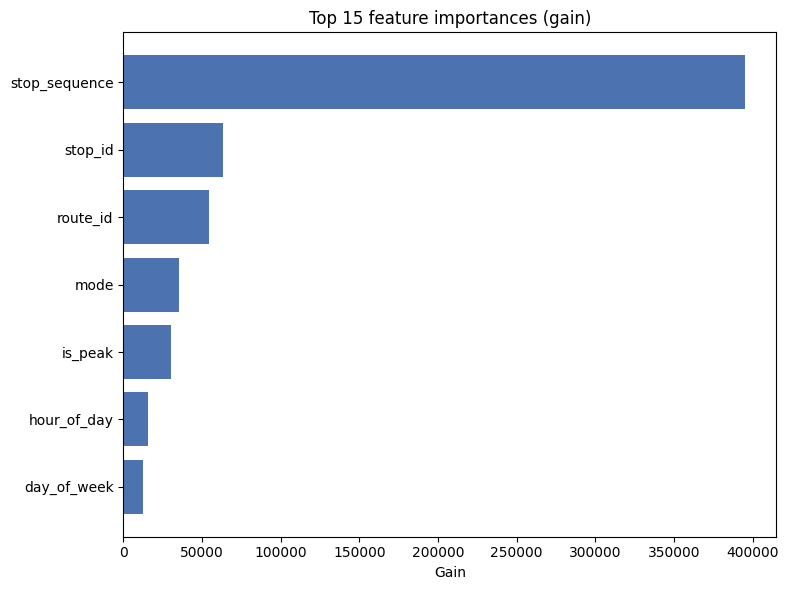

In [9]:
# Cell 9 — Top 15 feature importances (gain)
booster = model.get_booster()
importance = booster.get_score(importance_type='gain')
imp_series = pd.Series(importance).sort_values(ascending=False)

print('Top 15 feature importances (gain):')
print(imp_series.head(15).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
top15 = imp_series.head(15).sort_values()
ax.barh(top15.index.astype(str), top15.values, color='#4C72B0')
ax.set_title('Top 15 feature importances (gain)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()


## Residual analysis

Goal: find *where* the model is wrong so we know what to invest in next
(weather? more history? better features?). All residuals below are computed
on the held-out temporal test set only.

In [10]:
# Cell 10 — Compute residuals (predicted - actual) on the test set
residuals = y_pred - y_test.values
abs_error = np.abs(residuals)

print(f'Residual (predicted - actual) summary on test set (n={len(residuals):,}):')
print(f'  mean:   {residuals.mean():.3f} min')
print(f'  std:    {residuals.std():.3f} min')
print(f'  min:    {residuals.min():.3f} min')
print(f'  max:    {residuals.max():.3f} min')
print(f'  MAE:    {abs_error.mean():.3f} min  (matches Cell 8)')

test_analysis = X_test[['hour_of_day', 'mode', 'day_of_week']].copy()
test_analysis['actual'] = y_test.values
test_analysis['predicted'] = y_pred
test_analysis['residual'] = residuals
test_analysis['abs_error'] = abs_error
test_analysis.head()


Residual (predicted - actual) summary on test set (n=2,766,102):
  mean:   0.133 min
  std:    4.839 min
  min:    -458.848 min
  max:    1236.763 min
  MAE:    2.265 min  (matches Cell 8)


,hour_of_day,mode,day_of_week,actual,predicted,residual,abs_error
17254840,0,bus,Thursday,1.266667,-2.500500,-3.767167,3.767167
17254841,0,bus,Thursday,0.533333,-2.960718,-3.494052,3.494052
17254842,0,bus,Thursday,0.150000,-3.052740,-3.202740,3.202740
17254843,0,bus,Thursday,0.333333,-1.610468,-1.943802,1.943802
17254844,0,rail,Thursday,-0.500000,0.087464,0.587464,0.587464


## Residuals by hour_of_day

Mean absolute error per scheduled hour — flags hours the model is
systematically worse on.

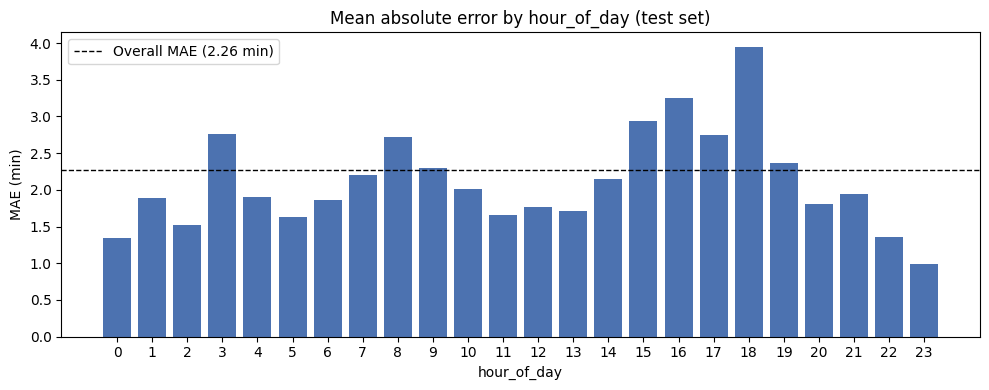

hour_of_day
0     1.345835
1     1.888441
2     1.520645
3     2.757817
4     1.903021
5     1.627854
6     1.859755
7     2.205579
8     2.720865
9     2.291894
10    2.009295
11    1.661989
12    1.770078
13    1.708512
14    2.148530
15    2.934445
16    3.246375
17    2.740564
18    3.949022
19    2.363408
20    1.806225
21    1.940767
22    1.360195
23    0.994431


In [11]:
# Cell 11 — Residuals by hour_of_day
mae_by_hour = test_analysis.groupby('hour_of_day', observed=True)['abs_error'].mean().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(mae_by_hour.index.astype(str), mae_by_hour.values, color='#4C72B0')
ax.axhline(abs_error.mean(), color='black', linestyle='--', linewidth=1,
           label=f'Overall MAE ({abs_error.mean():.2f} min)')
ax.set_title('Mean absolute error by hour_of_day (test set)')
ax.set_xlabel('hour_of_day')
ax.set_ylabel('MAE (min)')
ax.legend()
plt.tight_layout()
plt.show()

print(mae_by_hour.to_string())


## Residuals by mode

Is bus / rail / ferry error different?

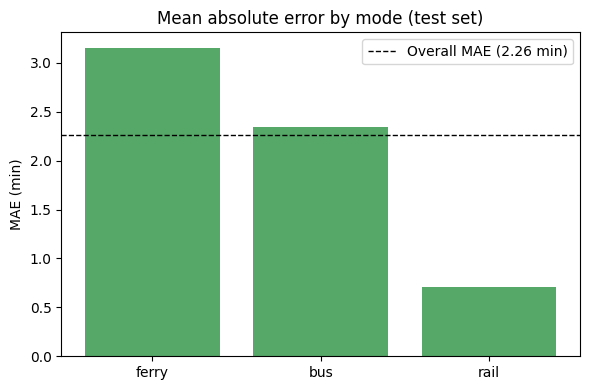

mode
ferry    3.154726
bus      2.343160
rail     0.713133


In [12]:
# Cell 12 — Residuals by mode
mae_by_mode = test_analysis.groupby('mode', observed=True)['abs_error'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mae_by_mode.index.astype(str), mae_by_mode.values, color='#55A868')
ax.axhline(abs_error.mean(), color='black', linestyle='--', linewidth=1,
           label=f'Overall MAE ({abs_error.mean():.2f} min)')
ax.set_title('Mean absolute error by mode (test set)')
ax.set_ylabel('MAE (min)')
ax.legend()
plt.tight_layout()
plt.show()

print(mae_by_mode.to_string())


## Residuals by day_of_week

Weekday vs weekend pattern check. Note: the temporal test split (Cell 6)
only covers the last two source_dates, so this may not include a full week —
see the printed date range below.

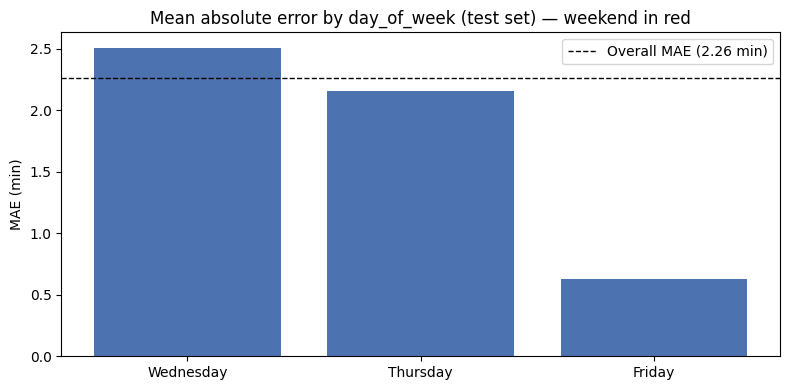

day_of_week
Wednesday    2.507820
Thursday     2.153621
Friday       0.627508

Days actually present in the test set: ['Friday', 'Thursday', 'Wednesday']


In [13]:
# Cell 13 — Residuals by day_of_week
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
mae_by_dow = test_analysis.groupby('day_of_week', observed=True)['abs_error'].mean()
mae_by_dow = mae_by_dow.reindex([d for d in DAY_ORDER if d in mae_by_dow.index])

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52' if d in ('Saturday', 'Sunday') else '#4C72B0' for d in mae_by_dow.index]
ax.bar(mae_by_dow.index.astype(str), mae_by_dow.values, color=colors)
ax.axhline(abs_error.mean(), color='black', linestyle='--', linewidth=1,
           label=f'Overall MAE ({abs_error.mean():.2f} min)')
ax.set_title('Mean absolute error by day_of_week (test set) — weekend in red')
ax.set_ylabel('MAE (min)')
ax.legend()
plt.tight_layout()
plt.show()

print(mae_by_dow.to_string())
print(f"\nDays actually present in the test set: {sorted(test_analysis['day_of_week'].unique())}")


## Residuals by source_date

Daily MAE across the test period — spikes on specific days would point at an
unmodeled external driver (e.g. weather/events) worth adding as a feature.
`source_date` was dropped from memory after the temporal split (Cell 6) to
save RAM, so it's reloaded here (same `load_path`) and aligned to the test
rows by their original row index.

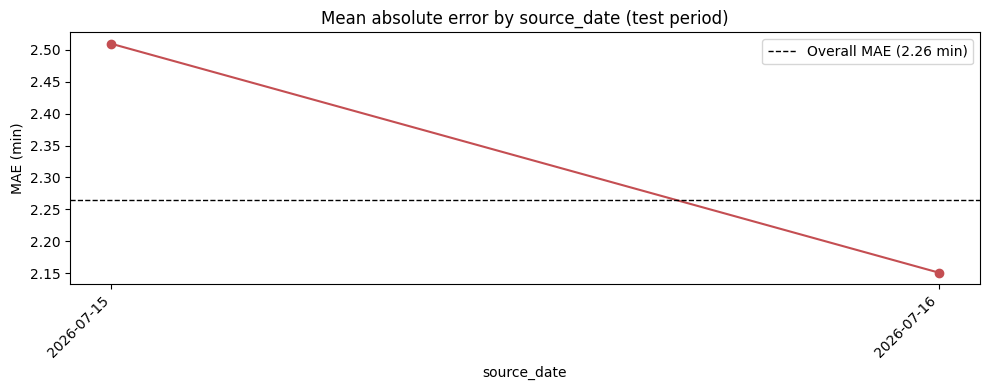

source_date
2026-07-15    2.509516
2026-07-16    2.150985

Test period spans 2 distinct source_date(s) — day-level spike detection has limited statistical power with so few days.


In [14]:
# Cell 14 — Residuals by source_date
source_date_test = pd.read_parquet(load_path, columns=['source_date'])['source_date'].astype(str)
test_analysis['source_date'] = source_date_test.loc[test_analysis.index].values
del source_date_test

mae_by_date = test_analysis.groupby('source_date')['abs_error'].mean().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mae_by_date.index.astype(str), mae_by_date.values, marker='o', color='#C44E52')
ax.axhline(abs_error.mean(), color='black', linestyle='--', linewidth=1,
           label=f'Overall MAE ({abs_error.mean():.2f} min)')
ax.set_title('Mean absolute error by source_date (test period)')
ax.set_xlabel('source_date')
ax.set_ylabel('MAE (min)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(mae_by_date.to_string())
print(f'\nTest period spans {len(mae_by_date)} distinct source_date(s) — '
      'day-level spike detection has limited statistical power with so few days.')


## Predicted vs. actual delay_minutes

Diagonal line = perfect prediction. The test set has ~2.8M rows, so a random
sample is plotted for readability (points would otherwise fully saturate the
figure).

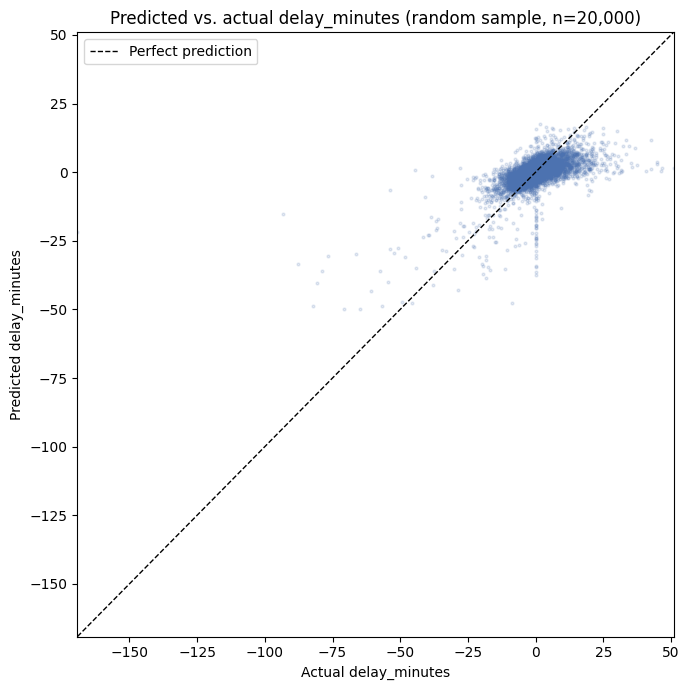

In [15]:
# Cell 15 — Scatter plot of predicted vs. actual delay_minutes
SAMPLE_N = 20_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(test_analysis), size=min(SAMPLE_N, len(test_analysis)), replace=False)

sample_actual = test_analysis['actual'].values[sample_idx]
sample_pred = test_analysis['predicted'].values[sample_idx]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(sample_actual, sample_pred, s=4, alpha=0.15, color='#4C72B0')
lims = [min(sample_actual.min(), sample_pred.min()), max(sample_actual.max(), sample_pred.max())]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual delay_minutes')
ax.set_ylabel('Predicted delay_minutes')
ax.set_title(f'Predicted vs. actual delay_minutes (random sample, n={len(sample_idx):,})')
ax.legend()
plt.tight_layout()
plt.show()


## Summary

In [16]:
# Cell 16 — Written summary of where the model is wrong
worst_hour = mae_by_hour.idxmax()
best_hour = mae_by_hour.idxmin()
hour_spread = mae_by_hour.max() - mae_by_hour.min()

worst_mode = mae_by_mode.idxmax()
best_mode = mae_by_mode.idxmin()
mode_spread = mae_by_mode.max() - mae_by_mode.min()

weekday_days = [d for d in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'] if d in mae_by_dow.index]
weekend_days = [d for d in ['Saturday', 'Sunday'] if d in mae_by_dow.index]
weekday_mae = mae_by_dow.reindex(weekday_days).mean() if weekday_days else float('nan')
weekend_mae = mae_by_dow.reindex(weekend_days).mean() if weekend_days else float('nan')

worst_date = mae_by_date.idxmax()
worst_date_mae = mae_by_date.max()
date_mean = mae_by_date.mean()
date_std = mae_by_date.std()
date_spike_ratio = (worst_date_mae - date_mean) / date_std if date_std and date_std > 0 else float('nan')

print('=== Residual analysis summary ===\n')
print(f'- hour_of_day: worst={worst_hour}h (MAE {mae_by_hour.max():.2f} min), '
      f'best={best_hour}h (MAE {mae_by_hour.min():.2f} min), spread={hour_spread:.2f} min')
print(f'- mode:        worst={worst_mode} (MAE {mae_by_mode.max():.2f} min), '
      f'best={best_mode} (MAE {mae_by_mode.min():.2f} min), spread={mode_spread:.2f} min')

if weekend_days:
    print(f'- day_of_week: weekday avg MAE={weekday_mae:.2f} min, weekend avg MAE={weekend_mae:.2f} min, '
          f'diff={weekday_mae - weekend_mae:+.2f} min')
else:
    print(f'- day_of_week: test period contains no weekend days (only '
          f'{sorted(test_analysis["day_of_week"].unique())}) — weekday/weekend comparison is not '
          'possible from this split; weekday MAE ranges '
          f'{mae_by_dow.min():.2f}-{mae_by_dow.max():.2f} min across '
          f'{list(mae_by_dow.index)}')

print(f'- source_date: worst day={worst_date} (MAE {worst_date_mae:.2f} min), '
      f'test-period mean={date_mean:.2f} min, std={date_std:.2f} min '
      f'({len(mae_by_date)} distinct test date(s) — limited statistical power)')
print()

dims = {'hour_of_day': hour_spread, 'mode': mode_spread}
if weekend_days:
    dims['day_of_week'] = abs(weekday_mae - weekend_mae)
biggest_dim = max(dims, key=dims.get)
print(f'Largest error spread is along **{biggest_dim}** '
      f'({dims[biggest_dim]:.2f} min swing between best/worst group).')

if len(mae_by_date) < 5:
    print(f'\nOnly {len(mae_by_date)} distinct source_date(s) fall in the test period, so this run cannot '
          'reliably confirm or rule out day-level spikes (e.g. storms/events) as an error driver — '
          'that needs a longer temporal test window before weather data can be justified on this '
          'evidence alone.')
elif date_spike_ratio >= 2:
    print(f'\n{worst_date} is a clear outlier ({date_spike_ratio:.1f} std above the test-period mean) — '
          'worth checking that date against weather/event records; if it correlates with a storm or '
          'major disruption, that supports adding a weather/event feature.')
else:
    print('\nNo single date stands out as a >2-std spike in the test period — the current signal does '
          'not strongly justify weather data on its own.')

print(f'\nOverall: {biggest_dim} shows the most systematic error variation in this run. Given the test '
      'window is only 2 days, the next highest-value investment is likely a longer backtest window '
      '(more history) to get a statistically meaningful read on day-to-day and weather-driven variance, '
      'rather than jumping straight to weather features on this evidence alone.')


=== Residual analysis summary ===

- hour_of_day: worst=18h (MAE 3.95 min), best=23h (MAE 0.99 min), spread=2.95 min
- mode:        worst=ferry (MAE 3.15 min), best=rail (MAE 0.71 min), spread=2.44 min
- day_of_week: test period contains no weekend days (only ['Friday', 'Thursday', 'Wednesday']) — weekday/weekend comparison is not possible from this split; weekday MAE ranges 0.63-2.51 min across ['Wednesday', 'Thursday', 'Friday']
- source_date: worst day=2026-07-15 (MAE 2.51 min), test-period mean=2.33 min, std=0.25 min (2 distinct test date(s) — limited statistical power)

Largest error spread is along **hour_of_day** (2.95 min swing between best/worst group).

Only 2 distinct source_date(s) fall in the test period, so this run cannot reliably confirm or rule out day-level spikes (e.g. storms/events) as an error driver — that needs a longer temporal test window before weather data can be justified on this evidence alone.

Overall: hour_of_day shows the most systematic error variation